<a href="https://colab.research.google.com/github/ChitraShreeK/Manufacturing-Defect-Analysis-and-Process-Improvement/blob/main/analyze_phase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

Saving manufacturing_Raw_Dataset.csv to manufacturing_Raw_Dataset (1).csv


In [23]:
df = pd.read_csv("manufacturing_Raw_Dataset.csv")
df.head()

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus,SupplierQuality_Band
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301,1,85-90
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631,1,85-90
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402,1,80-85
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870,1,85-90
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964,1,80-85


In [24]:
df.shape

(3240, 18)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductionVolume      3240 non-null   int64  
 1   ProductionCost        3240 non-null   float64
 2   SupplierQuality       3240 non-null   float64
 3   DeliveryDelay         3240 non-null   int64  
 4   DefectRate            3240 non-null   float64
 5   QualityScore          3240 non-null   float64
 6   MaintenanceHours      3240 non-null   int64  
 7   DowntimePercentage    3240 non-null   float64
 8   InventoryTurnover     3240 non-null   float64
 9   StockoutRate          3240 non-null   float64
 10  WorkerProductivity    3240 non-null   float64
 11  SafetyIncidents       3240 non-null   int64  
 12  EnergyConsumption     3240 non-null   float64
 13  EnergyEfficiency      3240 non-null   float64
 14  AdditiveProcessTime   3240 non-null   float64
 15  AdditiveMaterialCost 

In [26]:
df.isnull().sum()

,0
ProductionVolume,0
ProductionCost,0
SupplierQuality,0
DeliveryDelay,0
DefectRate,0
QualityScore,0
MaintenanceHours,0
DowntimePercentage,0
InventoryTurnover,0
StockoutRate,0


In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.describe()

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
count,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000
mean,548.523148,12423.018476,89.833290,2.558951,2.749116,80.134272,11.476543,2.501373,6.019662,0.050878,90.040115,4.591667,2988.494453,0.299776,5.472098,299.515479,0.840432
std,262.402073,4308.051904,5.759143,1.705804,1.310154,11.611750,6.872684,1.443684,2.329791,0.028797,5.723600,2.896313,1153.420820,0.116400,2.598212,116.379905,0.366261
min,100.000000,5000.174521,80.004820,0.000000,0.500710,60.010098,0.000000,0.001665,2.001611,0.000002,80.004960,0.000000,1000.720156,0.100238,1.000151,100.211137,0.000000
25%,322.000000,8728.829280,84.869219,1.000000,1.598033,70.103420,5.750000,1.264597,3.983249,0.026200,85.180203,2.000000,1988.140273,0.200502,3.228507,194.922058,1.000000
50%,549.000000,12405.204656,89.704861,3.000000,2.708775,80.265312,12.000000,2.465151,6.022389,0.051837,90.125743,5.000000,2996.822301,0.297470,5.437134,299.728918,1.000000
75%,775.250000,16124.462428,94.789936,4.000000,3.904533,90.353822,17.000000,3.774861,8.050222,0.075473,95.050838,7.000000,3984.788299,0.402659,7.741006,403.178283,1.000000
max,999.000000,19993.365549,99.989214,5.000000,4.998529,99.996993,23.000000,4.997591,9.998577,0.099997,99.996786,9.000000,4997.074741,0.499500,9.999749,499.982782,1.000000


In [29]:
# 1. Baseline statistics for DefectRate
df["DefectRate"].describe()

,DefectRate
count,3240.000000
mean,2.749116
std,1.310154
min,0.500710
25%,1.598033
50%,2.708775
75%,3.904533
max,4.998529


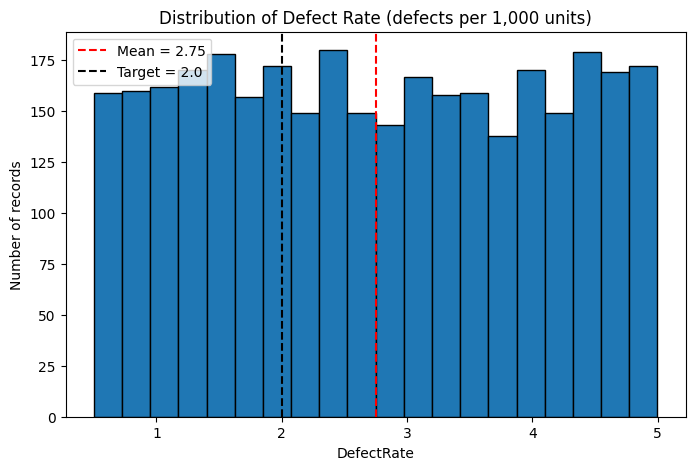

In [30]:
# 2. Histogram with mean and target lines
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["DefectRate"], bins=20, edgecolor="black")
plt.axvline(df["DefectRate"].mean(), color="red", linestyle="--", label="Mean = 2.75")
plt.axvline(2.0, color="black", linestyle="--", label="Target = 2.0")
plt.title("Distribution of Defect Rate (defects per 1,000 units)")
plt.xlabel("DefectRate")
plt.ylabel("Number of records")
plt.legend()
plt.show()

In [31]:
# 3. DefectStatus split
df["DefectStatus"].value_counts()
df["DefectStatus"].value_counts(normalize=True) * 100

,proportion
DefectStatus,
1,84.04321
0,15.95679


In [32]:
# 4. The sanity check: does DefectRate differ between DefectStatus 0 and 1?
df.groupby("DefectStatus")["DefectRate"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
DefectStatus,,,,,
0,517,2.010328,1.977584,0.511046,4.967665
1,2723,2.889386,3.027273,0.500710,4.998529


In [33]:
# % of records already at or below the target
(df["DefectRate"] <= 2.0).mean() * 100

np.float64(33.827160493827165)

In [34]:
# Baseline sigma level (assumption: DefectRate = defects per 1,000 units)
from scipy.stats import norm

dpmo = df["DefectRate"].mean() * 1000      # defects per million
sigma = norm.ppf(1 - dpmo/1_000_000) + 1.5  # standard 1.5 sigma shift
print(round(dpmo), round(sigma, 2))

2749 4.28


In [35]:
# Correlation of every numeric variable with DefectRate
numeric_df = df.select_dtypes(include="number")
correlations = numeric_df.corr()["DefectRate"].sort_values(ascending=False)
correlations

,DefectRate
DefectRate,1.000000
DefectStatus,0.245746
ProductionCost,0.014428
SafetyIncidents,0.012196
SupplierQuality,0.012157
AdditiveMaterialCost,0.011596
StockoutRate,0.007547
EnergyConsumption,0.005297
WorkerProductivity,-0.000388
MaintenanceHours,-0.008687


In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

features = ["SupplierQuality", "DeliveryDelay", "MaintenanceHours",
            "DowntimePercentage", "WorkerProductivity", "ProductionCost",
            "SafetyIncidents", "InventoryTurnover"]

X = df[features]
y = df["DefectRate"]

model = LinearRegression()
model.fit(X, y)

print("R² score:", model.score(X, y))
import pandas as pd
coef_df = pd.DataFrame({"Feature": features, "Coefficient": model.coef_})
print(coef_df.sort_values("Coefficient", ascending=False))

R² score: 0.0014449212009519652
              Feature  Coefficient
6     SafetyIncidents     0.005540
0     SupplierQuality     0.002945
5      ProductionCost     0.000005
4  WorkerProductivity    -0.000191
2    MaintenanceHours    -0.001576
7   InventoryTurnover    -0.007962
3  DowntimePercentage    -0.009321
1       DeliveryDelay    -0.017546


In [37]:
# Ranked factors by absolute correlation strength
ranked = numeric_df.corr()["DefectRate"].drop(["DefectRate", "DefectStatus"])
ranked_abs = ranked.abs().sort_values(ascending=False)

ranked_table = pd.DataFrame({
    "Factor": ranked_abs.index,
    "Correlation with DefectRate": ranked.loc[ranked_abs.index].round(4)
})
ranked_table

,Factor,Correlation with DefectRate
QualityScore,QualityScore,-0.0363
AdditiveProcessTime,AdditiveProcessTime,-0.0284
DeliveryDelay,DeliveryDelay,-0.0230
ProductionVolume,ProductionVolume,-0.0194
ProductionCost,ProductionCost,0.0144
EnergyEfficiency,EnergyEfficiency,-0.0142
InventoryTurnover,InventoryTurnover,-0.0141
SafetyIncidents,SafetyIncidents,0.0122
SupplierQuality,SupplierQuality,0.0122
AdditiveMaterialCost,AdditiveMaterialCost,0.0116


In [38]:
# Quick non-linear check: does MaintenanceHours relate to DefectRate in a non-straight-line way?
df.groupby(pd.cut(df["MaintenanceHours"], bins=5))["DefectRate"].mean()

/tmp/ipykernel_1678/2209946217.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["MaintenanceHours"], bins=5))["DefectRate"].mean()


,DefectRate
MaintenanceHours,
"(-0.023, 4.6]",2.767895
"(4.6, 9.2]",2.747567
"(9.2, 13.8]",2.752535
"(13.8, 18.4]",2.751653
"(18.4, 23.0]",2.725655


In [39]:
# Correlation of every numeric variable with DefectStatus (not DefectRate)
status_corr = numeric_df.corr()["DefectStatus"].drop("DefectStatus").sort_values(key=abs, ascending=False)
status_corr

,DefectStatus
MaintenanceHours,0.297107
DefectRate,0.245746
QualityScore,-0.199219
ProductionVolume,0.128973
StockoutRate,0.040574
SupplierQuality,0.038184
EnergyEfficiency,-0.035031
ProductionCost,0.026720
SafetyIncidents,-0.016039
InventoryTurnover,0.006733


In [40]:
import statsmodels.api as sm

# Predictors: MaintenanceHours and QualityScore
X = df[["MaintenanceHours", "QualityScore"]]
X = sm.add_constant(X)   # adds intercept term, standard practice
y = df["DefectStatus"]

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.370433
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           DefectStatus   No. Observations:                 3240
Model:                          Logit   Df Residuals:                     3237
Method:                           MLE   Df Model:                            2
Date:                Fri, 02 Oct 2026   Pseudo R-squ.:                  0.1561
Time:                        08:05:12   Log-Likelihood:                -1200.2
converged:                       True   LL-Null:                       -1422.2
Covariance Type:            nonrobust   LLR p-value:                 3.849e-97
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                4.7999      0.403     11.917      0.000       4.011       5.589
Maintenance

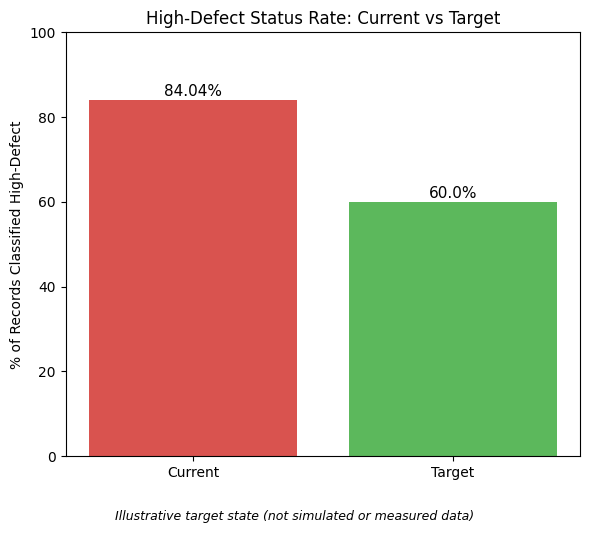

In [41]:
import matplotlib.pyplot as plt

# Chart 1: High-defect status % — current vs target
labels = ["Current", "Target"]
values = [84.04, 60]

plt.figure(figsize=(6,5))
bars = plt.bar(labels, values, color=["#d9534f", "#5cb85c"])
plt.title("High-Defect Status Rate: Current vs Target")
plt.ylabel("% of Records Classified High-Defect")
plt.ylim(0, 100)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f"{bar.get_height()}%", ha="center", fontsize=11)
plt.figtext(0.5, -0.05, "Illustrative target state (not simulated or measured data)",
            ha="center", fontsize=9, style="italic")
plt.tight_layout()
plt.show()

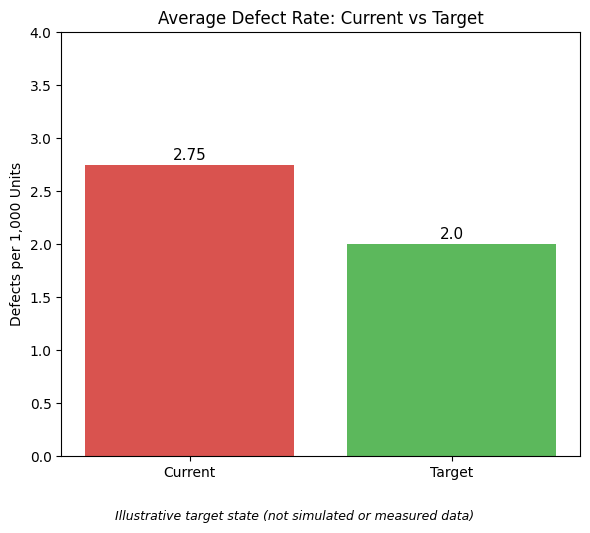

In [42]:
# Chart 2: Average DefectRate — current vs target
labels = ["Current", "Target"]
values = [2.75, 2.0]

plt.figure(figsize=(6,5))
bars = plt.bar(labels, values, color=["#d9534f", "#5cb85c"])
plt.title("Average Defect Rate: Current vs Target")
plt.ylabel("Defects per 1,000 Units")
plt.ylim(0, 4)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
              f"{bar.get_height()}", ha="center", fontsize=11)
plt.figtext(0.5, -0.05, "Illustrative target state (not simulated or measured data)",
            ha="center", fontsize=9, style="italic")
plt.tight_layout()
plt.show()